# ch255 — Law of Large Numbers

**Part VIII: Probability** | Computational Mathematics for Programmers

---

## 1. Two Different Claims About Sample Means

The Central Limit Theorem (ch254) describes the **distribution** of the sample mean. The Law of Large Numbers (LLN) makes a different, simpler claim: the sample mean **converges** to the true mean as n grows.

There are two versions:

**Weak LLN**: For any ε > 0:
$$\lim_{n \to \infty} P\left(|\bar{X}_n - \mu| > \varepsilon\right) = 0$$
The sample mean converges to μ **in probability**.

**Strong LLN**:
$$P\left(\lim_{n \to \infty} \bar{X}_n = \mu\right) = 1$$
The sample mean converges to μ **almost surely** — with probability 1.

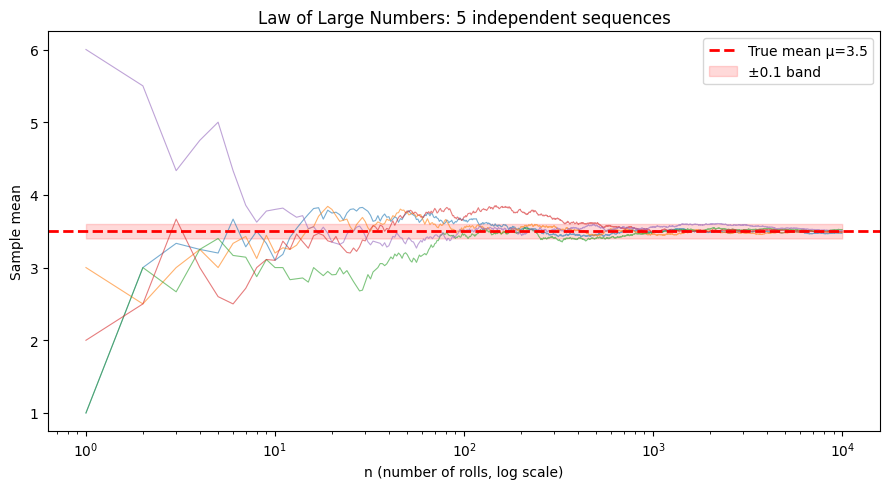

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Visualize LLN for several different starting sequences
rng = np.random.default_rng(seed=42)
n_max = 10_000
n_sequences = 5
mu_true = 3.5  # true mean for fair die

fig, ax = plt.subplots(figsize=(9, 5))
ns = np.arange(1, n_max + 1)

for i in range(n_sequences):
    rolls = rng.integers(1, 7, size=n_max).astype(float)
    running_means = np.cumsum(rolls) / ns
    ax.plot(ns, running_means, alpha=0.6, linewidth=0.8)

ax.axhline(mu_true, color='red', linestyle='--', linewidth=2, label=f'True mean μ={mu_true}')
ax.set_xscale('log')
ax.fill_between(ns, mu_true - 0.1, mu_true + 0.1, alpha=0.15, color='red', label='±0.1 band')
ax.set_xlabel('n (number of rolls, log scale)')
ax.set_ylabel('Sample mean')
ax.set_title('Law of Large Numbers: 5 independent sequences')
ax.legend()
plt.tight_layout()
plt.show()

## 2. The Weak LLN via Chebyshev's Inequality

A direct proof of the weak LLN uses **Chebyshev's inequality**:
$$P(|X - \mu| \geq k\sigma) \leq \frac{1}{k^2}$$

or equivalently, for any ε > 0:
$$P(|X - \mu| \geq \varepsilon) \leq \frac{\text{Var}(X)}{\varepsilon^2}$$

Apply to X̄ₙ, which has mean μ and variance σ²/n:
$$P(|\bar{X}_n - \mu| \geq \varepsilon) \leq \frac{\sigma^2}{n\varepsilon^2} \to 0 \text{ as } n \to \infty$$

In [2]:
# Chebyshev's inequality: P(|X - mu| >= epsilon) <= Var(X) / epsilon^2
# For sample mean X̄_n: Var = sigma^2/n

sigma2 = 35/12  # variance of fair die
epsilon = 0.1   # tolerance

n_values = np.array([10, 100, 1_000, 10_000, 100_000])
chebyshev_bound = sigma2 / (n_values * epsilon**2)

print(f"Chebyshev bound: P(|X̄_n - μ| >= {epsilon}) <= σ²/(n·ε²)")
print(f"\n{'n':>10} {'Bound':>12}")
print("-" * 25)
for n, bound in zip(n_values, chebyshev_bound):
    print(f"{n:>10,} {bound:>12.6f}")

# Verify empirically at n=1000
rng = np.random.default_rng(seed=0)
n = 1_000
n_trials = 100_000
means = rng.integers(1, 7, size=(n_trials, n)).mean(axis=1)
empirical_prob = np.mean(np.abs(means - 3.5) >= epsilon)
theoretical_bound = sigma2 / (n * epsilon**2)

print(f"\nEmpirical P(|X̄_{n} - 3.5| >= {epsilon}) = {empirical_prob:.5f}")
print(f"Chebyshev bound = {theoretical_bound:.5f}")
print(f"Bound is valid (empirical <= bound): {empirical_prob <= theoretical_bound}")

Chebyshev bound: P(|X̄_n - μ| >= 0.1) <= σ²/(n·ε²)

         n        Bound
-------------------------
        10    29.166667
       100     2.916667
     1,000     0.291667
    10,000     0.029167
   100,000     0.002917

Empirical P(|X̄_1000 - 3.5| >= 0.1) = 0.06471
Chebyshev bound = 0.29167
Bound is valid (empirical <= bound): True


## 3. LLN vs CLT: What Each Says

| Theorem | Statement | What it tells you |
|---------|-----------|-------------------|
| LLN | X̄ₙ → μ as n → ∞ | Sample mean converges to true mean |
| CLT | (X̄ₙ − μ)/(σ/√n) → N(0,1) | Distribution of fluctuations around μ |

LLN says the noise vanishes. CLT says how the noise is distributed while it's still there.

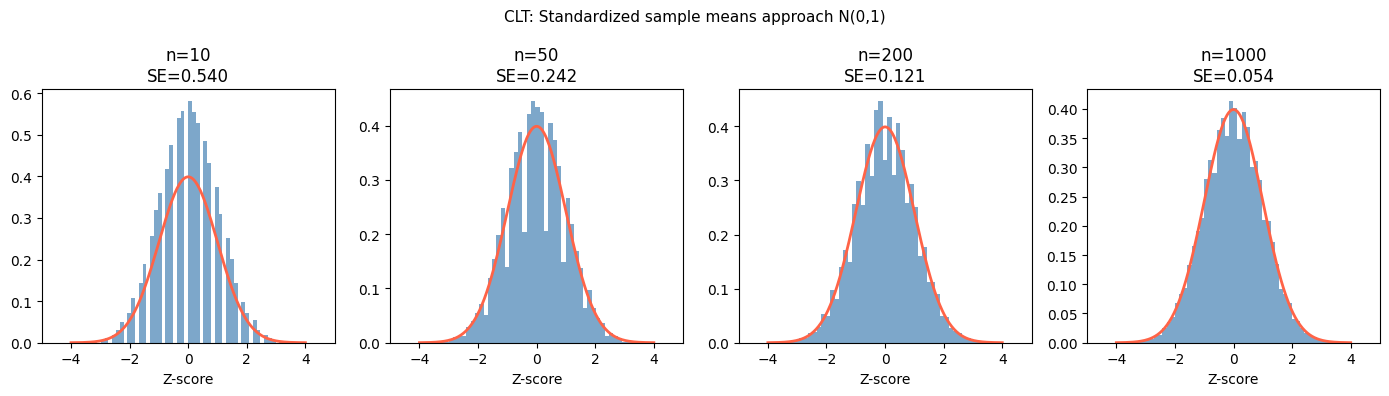

In [3]:
# Visualize: LLN (convergence) vs CLT (distribution of fluctuations)
rng = np.random.default_rng(seed=42)
n_values = [10, 50, 200, 1000]
n_trials = 50_000
sigma_die = np.sqrt(35/12)
mu_die = 3.5

fig, axes = plt.subplots(1, 4, figsize=(14, 4))

for ax, n in zip(axes, n_values):
    means = rng.integers(1, 7, size=(n_trials, n)).mean(axis=1)
    # Standardize: (X̄ - μ) / (σ/√n)
    z_scores = (means - mu_die) / (sigma_die / np.sqrt(n))
    
    from scipy import stats
    ax.hist(z_scores, bins=60, density=True, color='steelblue', alpha=0.7)
    x_norm = np.linspace(-4, 4, 200)
    ax.plot(x_norm, stats.norm.pdf(x_norm), 'tomato', linewidth=2)
    ax.set_title(f'n={n}\nSE={sigma_die/np.sqrt(n):.3f}')
    ax.set_xlim(-5, 5)
    ax.set_xlabel('Z-score')

fig.suptitle('CLT: Standardized sample means approach N(0,1)', fontsize=11)
plt.tight_layout()
plt.show()

## 4. Implications for Monte Carlo Methods

The LLN is the theoretical guarantee behind all Monte Carlo estimation *(ch256)*. If you estimate E[f(X)] by averaging f over N samples:
$$\hat{\mu}_N = \frac{1}{N} \sum_{i=1}^{N} f(X_i) \to E[f(X)] \text{ as } N \to \infty$$

This convergence is guaranteed by the LLN, and the CLT tells you the error rate is O(1/√N).

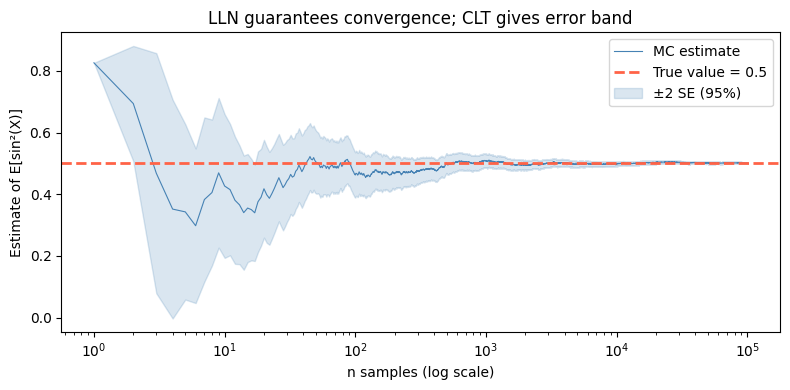

Final estimate (n=100,000): 0.500901
True value: 0.500000
Error: 0.000901


In [4]:
# Monte Carlo estimation of E[sin²(X)] for X ~ Uniform(0, π)
# True value: (1/π) ∫₀^π sin²(x) dx = 0.5

rng = np.random.default_rng(seed=0)
true_value = 0.5
n_max = 100_000

X = rng.uniform(0, np.pi, n_max)
f_X = np.sin(X)**2
ns = np.arange(1, n_max + 1)
estimates = np.cumsum(f_X) / ns

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(ns, estimates, color='steelblue', linewidth=0.8, label='MC estimate')
ax.axhline(true_value, color='tomato', linestyle='--', linewidth=2, label='True value = 0.5')

# Confidence band using CLT: ±2σ/√n
running_var = np.cumsum(f_X**2) / ns - (np.cumsum(f_X) / ns)**2
se = np.sqrt(np.maximum(running_var, 0) / ns)
ax.fill_between(ns, estimates - 2*se, estimates + 2*se, alpha=0.2, color='steelblue', label='±2 SE (95%)')

ax.set_xscale('log')
ax.set_xlabel('n samples (log scale)')
ax.set_ylabel('Estimate of E[sin²(X)]')
ax.set_title('LLN guarantees convergence; CLT gives error band')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Final estimate (n={n_max:,}): {estimates[-1]:.6f}")
print(f"True value: {true_value:.6f}")
print(f"Error: {abs(estimates[-1] - true_value):.6f}")

## 5. Summary

- The LLN says the sample mean converges to the population mean as n → ∞.
- The weak LLN is provable via Chebyshev's inequality using only finite variance.
- The LLN justifies all Monte Carlo estimation: average enough samples and you get the true expected value.
- Together with the CLT, it tells you both that estimates converge (LLN) and how quickly the error shrinks (CLT: rate 1/√n).

---

## 6. Forward References

Monte Carlo methods (ch256) put the LLN to work: estimating intractable integrals by sampling. Markov Chain Monte Carlo (MCMC) extends this to dependent samples from complex distributions, justified by ergodic theorems that generalize the LLN to Markov chains (ch257). The 1/√n convergence rate is the basis for sample size calculations in A/B testing (Part IX, ch286).